# **2-ух кубитное состояние Белла, как "Hello world"**

## **Шаг 1: Анализ состояния Белла с помощью схемы**

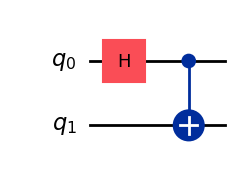

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0,1)

qc.draw(output="mpl")

In [2]:
from qiskit.quantum_info import Pauli

ZZ = Pauli('ZZ')
ZI = Pauli('ZI')
IZ = Pauli('IZ')
XX = Pauli('XX')
XI = Pauli('XI')
IX = Pauli('IX')

observables = [ZZ, ZI, IZ, XX, XI, IX]


## **Шаг 2: Оптимизация**

### Смотреть шаг 2 - в n-кубитном GHZ состоянии 

## **Шаг 3: Выполнение на бэкенде**

In [3]:
from qiskit_aer.primitives import Estimator

estimator = Estimator()

job = estimator.run([qc]*len(observables), observables)

job.result()

EstimatorResult(values=array([ 1.        ,  0.00585938,  0.00585938,  1.        , -0.01171875,
       -0.01171875]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0025176, 'sample_measure_time': 0.0011377, 'input_qubit_map': [[0, 0], [1, 1]], 'max_memory_mb': 14188, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 12, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9999656677246094, 'simulator_metadata': [{'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [0, 1], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 2, 'num_clbits': 2, 'time_taken': 0.0025176, 'sample_measure_time': 0.0011

## **Шаг 4: Обработка и построение графиков**

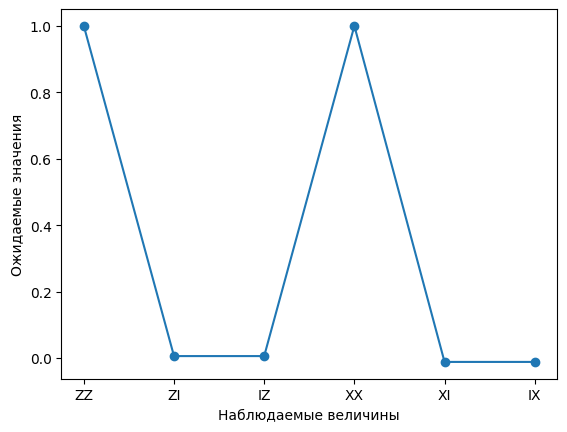

In [4]:
import matplotlib.pyplot as plt

data = ['ZZ', 'ZI', 'IZ', 'XX', 'XI', 'IX']
values = job.result().values

plt.plot(data, values, "-o")
plt.xlabel("Наблюдаемые величины")
plt.ylabel("Ожидаемые значения")
plt.show()

# **GHZ $n$-кубитное состояние**

## **Шаг 1: Анализ задачи с помощью схемы**

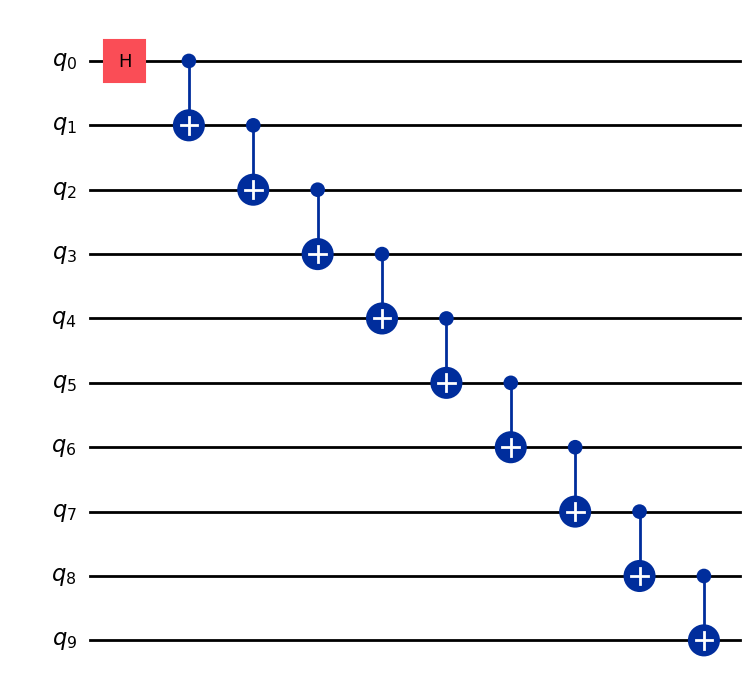

In [4]:
from qiskit import QuantumCircuit
def get_qc_for_nqubit_GHZ_state(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i+1)
    return qc

n = 10
qc = get_qc_for_nqubit_GHZ_state(n)
qc.draw(output="mpl")

In [52]:
from qiskit.quantum_info import SparsePauliOp

operator_strings = ['Z' + 'I' * i + 'Z' + 'I' * (n - i - 2) for i in range(n-1)]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(s) for s in operator_strings]

['ZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

## **Шаг 2: Оптимизация**

### С помощью реального устройства

In [53]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService()
backend = service.least_busy(simulator = False, operational = True)
if backend:
    print("Бэкенд получен - " + backend.name)
else:
    print("Бэкенд НЕ получен")

pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
qc_transpiled = pass_manager.run(qc)
operators_transpiled_list = [op.apply_layout(qc_transpiled.layout) for op in operators]

Бэкенд получен - ibm_fez


### С помощью мнимого устройства ibm_marrakesh

In [ ]:
# from qiskit_ibm_runtime.fake_provider import FakeMarrakesh

# fake_backend = FakeMarrakesh()

# # pass_manager = generate_preset_pass_manager(optimization_level=1, backend=fake_backend)

# qc_transpiled = pass_manager.run(qc)
# operators_transpiled_list = [op.apply_layout(qc_transpiled.layout) for op in operators]

## **Шаг 3: Выполнение на бэкенде**

### Для реального устройства

In [54]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions

options = EstimatorOptions()

options.resilience_level = 1
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = 'XY4'
estimator = Estimator(mode=backend, options=options)

job = estimator.run([(qc_transpiled, operators_transpiled_list)])
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d72oljuv3u3c73eiu4ng


### Для мнимого устройства

In [ ]:
# fake_backend = FakeMarrakesh()

# options = EstimatorOptions()

# estimator = Estimator(mode=fake_backend, options=options)

# job = estimator.run([(qc_transpiled, operators_transpiled_list)])
# print(f">>> Job ID: {job.job_id()}")

>>> Job ID: 29b42ae1-21fb-4e1c-a8e3-4798f3a56c8e


## **Шаг 4: Обработка результатов и построение графиков**

In [ ]:

job_id = "d72oljuv3u3c73eiu4ng"
job = service.job(job_id)

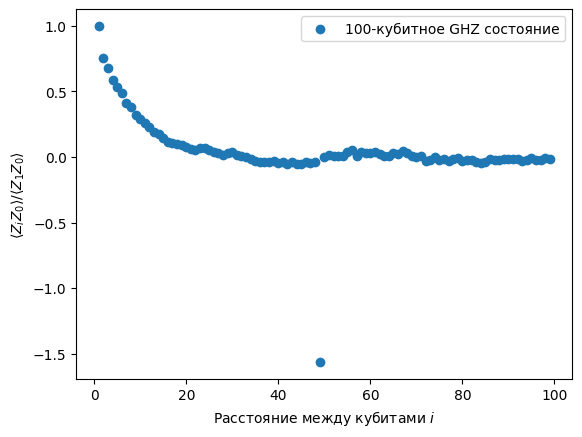

In [57]:
import matplotlib.pyplot as plt

data = list(range(1, len(operators)+1))
result = job.result()[0]
values = result.data.evs
values = [v / values[0] for v in values]

plt.scatter(data, values, marker = 'o', label = "100-кубитное GHZ состояние")
plt.xlabel("Расстояние между кубитами $i$")
plt.ylabel(r"$\langle Z_i Z_0 \rangle / \langle Z_1 Z_0 \rangle $")

plt.legend()
plt.show()